# Programming Backpropagation in Neural Networks

## 📚 Learning Objectives

By completing this notebook, you will:
- Program backpropagation in neural networks using differentiation techniques
- Understand the chain rule in neural network context
- Implement forward and backward propagation from scratch
- Apply backpropagation to train a simple neural network

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 03 "Solving the XOR Problem Using a Neural Network in Keras" — Keras trained that network for you; here you write the chain rule that made it possible.

**Used later in:** Course 08 (AIAT 122) — Unit 1, lesson 05 "Backpropagation Detailed" — which deepens this by checking your hand-derived gradients against PyTorch autograd.

---

This notebook covers practical activities from **Course 03, Unit 2**:
- Programming backpropagation in neural networks using differentiation techniques

---

## Introduction

**Backpropagation** is the algorithm that enables training of neural networks by computing gradients of the loss function with respect to all network parameters using the chain rule of calculus.


---

## 📌 Real case: four pages that made hidden layers useful

Rumelhart, Hinton and Williams, *Nature* 323, 533–536 (October 1986): **"Learning representations by
back-propagating errors."** Four pages. The algorithm inside was not new mathematics — it is the chain
rule, and Seppo Linnainmaa had published the general reverse-mode procedure in 1970, sixteen years earlier,
to nearly no attention. What the 1986 paper demonstrated was that propagating the error backwards through
the layers caused the *hidden* units to develop useful internal representations that nobody had designed.
Before that, a hidden layer was a layer you did not know how to train.

The XOR network below is the same demonstration. A single perceptron cannot separate XOR with a straight
line (Course 01, Unit 3, lesson 02 showed you that failure). Two layers can — but only if you can compute
how the hidden layer's weights should change, and that is exactly what the backward pass in this notebook
does, by hand, in about fifteen lines.

**What goes wrong without this.** Without a way to assign credit backwards, every weight that is not
directly attached to the output is untrainable. Your network is a fixed random feature extractor with one
trainable layer on top. Backpropagation is the answer to "which of my 60 million weights caused this error,
and by how much" — computed for all of them in one backward sweep.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy for the math, Matplotlib for the training curves — backprop needs nothing heavier.

import numpy as np
import matplotlib.pyplot as plt

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nProgramming Backpropagation in Neural Networks")
print("=" * 60)

✅ Libraries imported!

Programming Backpropagation in Neural Networks


## Part 1: Simple Neural Network with Backpropagation


In [2]:
# Define the network's building blocks: sigmoid/ReLU activations, their derivatives, and the MSE loss.
# Backprop is nothing but the chain rule, so every forward function comes paired with its derivative.

print("=" * 60)
print("Part 1: Simple Neural Network with Backpropagation")
print("=" * 60)

# Activation functions
def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    """Derivative of sigmoid"""
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    """ReLU activation function"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU"""
    return (x > 0).astype(float)

# Loss function
def mse_loss(y_pred, y_true):
    """Mean Squared Error loss"""
    return np.mean((y_pred - y_true) ** 2)

def mse_loss_derivative(y_pred, y_true):
    """Derivative of MSE loss"""
    return 2 * (y_pred - y_true) / len(y_true)

print("\n✅ Activation and loss functions defined!")

Part 1: Simple Neural Network with Backpropagation

✅ Activation and loss functions defined!


In [3]:
# Wire the pieces into a trainable 2-layer network: forward pass, backward pass (chain rule), weight update.
# Each method below is one stage of the training loop that deep-learning frameworks automate.

# Simple 2-layer neural network class with backpropagation
class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.learning_rate = learning_rate
        np.random.seed(42)
        # init scale 1.0: with 0.1 the sigmoid net plateaus at 0.5 on XOR
        self.W1 = np.random.randn(input_size, hidden_size) * 1.0
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 1.0
        self.b2 = np.zeros((1, output_size))
    # Forward pass: input -> hidden (sigmoid) -> output (sigmoid); save intermediates for backprop.
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2
    # Backward pass: chain rule layer by layer — output error first, then propagated to layer 1.
    def backward(self, X, y, y_pred):
        m = X.shape[0]
        dz2 = mse_loss_derivative(y_pred, y) * sigmoid_derivative(self.z2)
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        da1 = dz2 @ self.W2.T
        dz1 = da1 * sigmoid_derivative(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        return dW1, db1, dW2, db2
    # Gradient descent step: nudge every weight against its gradient.
    def update_weights(self, dW1, db1, dW2, db2):
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
    # Training loop: forward, measure loss, backward, update — repeated for `epochs` rounds.
    def train(self, X, y, epochs=1000):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = mse_loss(y_pred, y)
            losses.append(loss)
            dW1, db1, dW2, db2 = self.backward(X, y, y_pred)
            self.update_weights(dW1, db1, dW2, db2)
        return losses



Example: XOR Problem

Training data:
X: [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [0 1 1 0]

Training network...

Results:

Input | Expected | Predicted | Correct
--------------------------------------------------
[0 0] |     0.00 |   0.0297 | ✓
[0 1] |     1.00 |   0.9600 | ✓
[1 0] |     1.00 |   0.9556 | ✓
[1 1] |     0.00 |   0.0512 | ✓


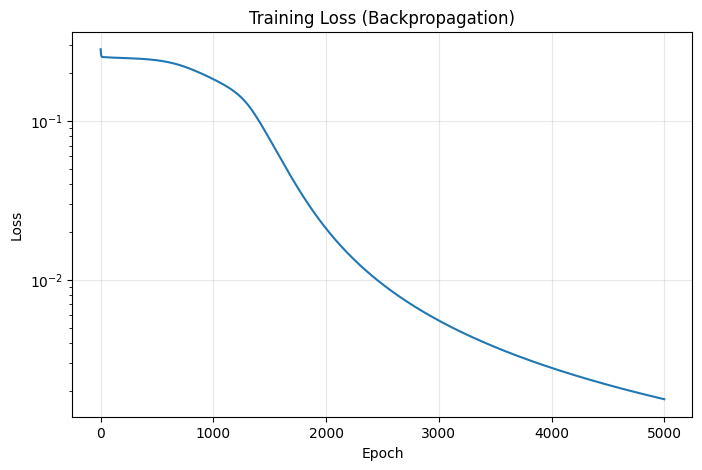


✅ Backpropagation training completed!


In [4]:
# Example: Train network on XOR problem
print("\n" + "=" * 60)
print("Example: XOR Problem")
print("=" * 60)

# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

print("\nTraining data:")
print("X:", X_xor)
print("y:", y_xor.flatten())

# Create and train network
# lr 2.0: the 2/n-scaled MSE gradient needs a larger step to escape the XOR plateau
nn = SimpleNeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=2.0)
print("\nTraining network...")
losses = nn.train(X_xor, y_xor, epochs=5000)

# Test predictions
predictions = nn.forward(X_xor)
print("\n" + "=" * 60)
print("Results:")
print("=" * 60)
print("\nInput | Expected | Predicted | Correct")
print("-" * 50)
for i in range(len(X_xor)):
    pred = predictions[i, 0]
    expected = y_xor[i, 0]
    correct = "✓" if abs(pred - expected) < 0.5 else "✗"
    print(f"{X_xor[i]} | {expected:8.2f} | {pred:8.4f} | {correct}")

# Visualize training
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Backpropagation)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Backpropagation training completed!")

**Read the figure.** Log-scaled loss against epoch for the run just printed — the same network whose four
predictions came out right above. The weights are seeded (`np.random.seed(42)`), so this curve is the same
every time the notebook is run.

- The curve **barely moves for the first thousand epochs**: 0.283 at epoch 0, 0.241 at epoch 500, still
  0.151 at epoch 1,200. On the log axis that stretch reads as an almost flat shelf. A loss near 0.25 is
  exactly what you get by predicting **0.5 for all four inputs** — the network is outputting the average
  and has learned nothing about XOR yet.
- Then it **falls off the shelf**: 0.151 at epoch 1,200 down to 0.0094 at 2,500 and 0.0018 by 5,000, two
  orders of magnitude in the second half of training. Nothing was changed at that point; the hidden layer
  found a representation that separates XOR, and from there every gradient step pays off.
- That shelf is why the learning rate in the cell above is **2.0** and not a cautious 0.1. Re-run the same
  seeded network with `learning_rate=0.1` and after 5,000 epochs the loss is 0.2485 — it never leaves the
  shelf at all.
- Read on a linear axis the whole thing would look like one sudden drop. The log axis is what shows the
  plateau and the steady late progress at the same time, which is why training curves are almost always
  plotted this way.

## Part 2: Understanding the Chain Rule in Backpropagation


In [5]:
# Zoom in on the chain rule with the smallest possible network: one weight, one input.
# Computing dL/dw factor by factor — and checking it numerically — is backpropagation in miniature.

print("\n" + "=" * 60)
print("Part 2: Understanding the Chain Rule in Backpropagation")
print("=" * 60)

# Smallest possible network: one input, one weight, sigmoid, squared error
#   z = w*x        (pre-activation)
#   a = sigmoid(z) (activation)
#   L = (a - y)^2  (loss)
# Chain rule:  dL/dw = (dL/da) * (da/dz) * (dz/dw)

x, y_true, w = 1.5, 1.0, 0.8

# Forward pass
z = w * x
a = sigmoid(z)
L = (a - y_true) ** 2
print(f"\nForward pass:  z = w·x = {z:.4f},  a = sigmoid(z) = {a:.4f},  L = (a-y)² = {L:.6f}")

# Backward pass: each chain-rule factor separately
dL_da = 2 * (a - y_true)          # derivative of (a-y)² with respect to a
da_dz = sigmoid_derivative(z)     # derivative of sigmoid
dz_dw = x                         # derivative of w*x with respect to w
dL_dw = dL_da * da_dz * dz_dw

print("\nChain rule factors:")
print(f"  dL/da = 2(a - y) = {dL_da:.6f}")
print(f"  da/dz = σ'(z)    = {da_dz:.6f}")
print(f"  dz/dw = x        = {dz_dw:.6f}")
print(f"  dL/dw = product  = {dL_dw:.6f}")

# Best practice: verify the analytical gradient numerically
eps = 1e-6
L_plus = (sigmoid((w + eps) * x) - y_true) ** 2
L_minus = (sigmoid((w - eps) * x) - y_true) ** 2
dL_dw_numerical = (L_plus - L_minus) / (2 * eps)
print(f"\nNumerical gradient check: (L(w+ε) - L(w-ε)) / 2ε = {dL_dw_numerical:.6f}")
print(f"Difference from analytical: {abs(dL_dw - dL_dw_numerical):.2e}")
assert abs(dL_dw - dL_dw_numerical) < 1e-7
print("\n✅ Chain rule verified against a numerical gradient —")
print("   backpropagation is exactly this product, applied layer by layer!")


Part 2: Understanding the Chain Rule in Backpropagation

Forward pass:  z = w·x = 1.2000,  a = sigmoid(z) = 0.7685,  L = (a-y)² = 0.053581

Chain rule factors:
  dL/da = 2(a - y) = -0.462950
  da/dz = σ'(z)    = 0.177894
  dz/dw = x        = 1.500000
  dL/dw = product  = -0.123534

Numerical gradient check: (L(w+ε) - L(w-ε)) / 2ε = -0.123534
Difference from analytical: 3.49e-11

✅ Chain rule verified against a numerical gradient —
   backpropagation is exactly this product, applied layer by layer!


### 🧪 What depth does to the gradient

Part 2 computed one chain-rule factor: `da/dz = σ'(z) = 0.177894`. Backpropagation multiplies one such
factor per layer. Baseline: one sigmoid layer. Change one thing: the depth — 1, 2, 5, 10, 20, 50 identical
layers. Then change the activation to ReLU and repeat. Measure: how much of the gradient still reaches the
first layer.

In [6]:
# Comparative experiment: gradient survival through depth, sigmoid vs ReLU.
# We chain the same unit L times:  z_(l+1) = w * a_l,  a_(l+1) = f(z_(l+1)).
# The factor that backpropagation carries from the loss to layer 1 is the PRODUCT of
# (w * f'(z_l)) over all layers - exactly the product Part 2 computed for a single layer.

def gradient_survival(depth, kind, x=1.5, w=1.0):
    """Return the product of per-layer chain-rule factors for a depth-L chain."""
    a, product = x, 1.0
    for _ in range(depth):
        z = w * a
        if kind == "sigmoid":
            product *= w * sigmoid_derivative(z)
            a = sigmoid(z)
        else:                                   # ReLU
            product *= w * float(relu_derivative(np.array([z]))[0])
            a = relu(z)
    return product

print(f"{'layers':>7} {'sigmoid chain':>18} {'ReLU chain':>14}")
print("-" * 42)
for depth in [1, 2, 5, 10, 20, 50]:
    print(f"{depth:>7} {gradient_survival(depth, 'sigmoid'):>18.3e} "
          f"{gradient_survival(depth, 'relu'):>14.3e}")

print()
print("Conclusion the numbers support: sigma'(z) can never exceed 0.25, so every sigmoid layer")
print("shrinks the gradient. After 20 layers essentially nothing reaches the front of the network -")
print("those weights receive no signal and stay at their initial values, however long you train.")
print("ReLU's derivative is exactly 1 wherever its input is positive, so the product does not decay.")
print("That single difference in a derivative is a large part of why networks got deep after 2010.")
print("(The mirror-image failure exists too: make w large enough and the product EXPLODES instead,")
print(" which is what gradient clipping is for.)")

 layers      sigmoid chain     ReLU chain
------------------------------------------
      1          1.491e-01      1.000e+00
      2          3.169e-02      1.000e+00
      5          3.544e-04      1.000e+00
     10          2.030e-07      1.000e+00
     20          6.662e-14      1.000e+00
     50          2.355e-33      1.000e+00

Conclusion the numbers support: sigma'(z) can never exceed 0.25, so every sigmoid layer
shrinks the gradient. After 20 layers essentially nothing reaches the front of the network -
those weights receive no signal and stay at their initial values, however long you train.
ReLU's derivative is exactly 1 wherever its input is positive, so the product does not decay.
That single difference in a derivative is a large part of why networks got deep after 2010.
(The mirror-image failure exists too: make w large enough and the product EXPLODES instead,
 which is what gradient clipping is for.)


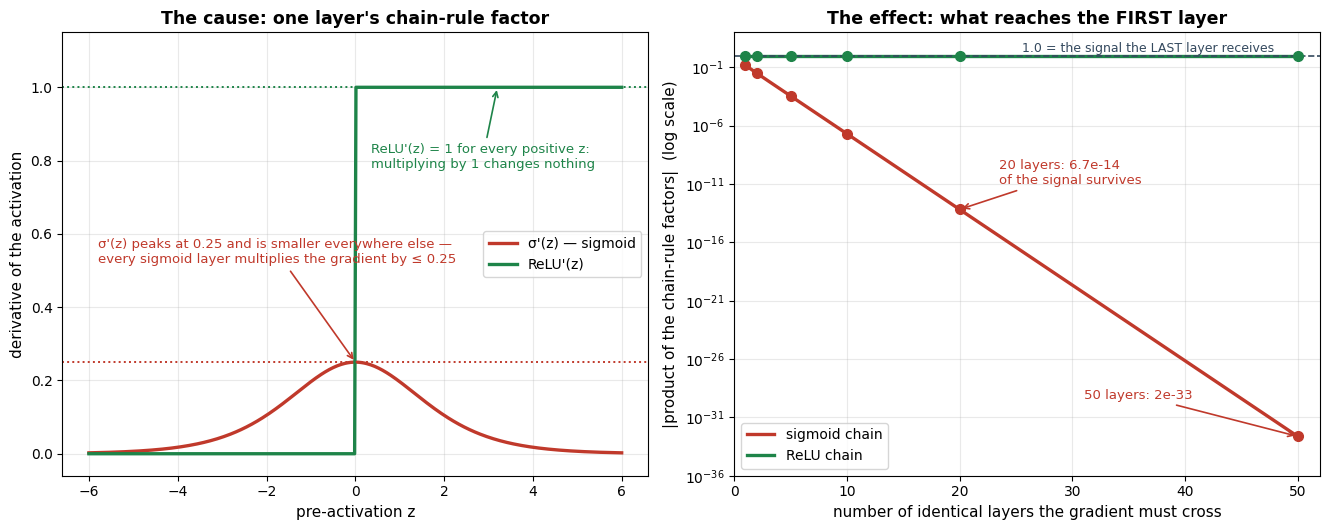

Every extra sigmoid layer multiplies the surviving gradient by this much:
  measured ratio, layer 10 -> 11 : 0.2247
  measured ratio, layer 30 -> 31 : 0.2247
  same ratio for ReLU            : 1.0000

A constant factor below 1, applied once per layer, is exponential decay — which is
why the red line is straight on a log axis. The green line is flat for the same
reason: its constant factor is exactly 1.


In [7]:
# The table above, drawn — plus the reason underneath it. WHY plot it: "2.355e-33" is a
# number a student can read without feeling. Fifty layers of collapse on a log axis is a
# cliff you can point at. Left panel = the CAUSE (one layer's derivative), right = the
# EFFECT (all the layers multiplied together).

depths = np.arange(1, 51)
sig_chain = np.array([gradient_survival(d, "sigmoid") for d in depths])
relu_chain = np.array([gradient_survival(d, "relu") for d in depths])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.4))

# ---- Left: the single factor that gets multiplied once per layer.
zs = np.linspace(-6, 6, 400)
axL.plot(zs, sigmoid_derivative(zs), color="#c0392b", lw=2.4, label="σ'(z) — sigmoid")
axL.plot(zs, relu_derivative(zs), color="#1e8449", lw=2.4, label="ReLU'(z)")
axL.axhline(1.0, color="#1e8449", ls=":", lw=1.4)
axL.axhline(0.25, color="#c0392b", ls=":", lw=1.4)
axL.annotate("σ'(z) peaks at 0.25 and is smaller everywhere else —\n"
             "every sigmoid layer multiplies the gradient by ≤ 0.25",
             xy=(0, 0.25), xytext=(-5.8, 0.52), fontsize=9.5, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
axL.annotate("ReLU'(z) = 1 for every positive z:\nmultiplying by 1 changes nothing",
             xy=(3.2, 1.0), xytext=(0.35, 0.78), fontsize=9.5, color="#1e8449",
             arrowprops=dict(arrowstyle="->", color="#1e8449", lw=1.2))
axL.set_xlabel("pre-activation z", fontsize=11)
axL.set_ylabel("derivative of the activation", fontsize=11)
axL.set_title("The cause: one layer's chain-rule factor",
              fontsize=12.5, fontweight="bold")
axL.set_ylim(-0.06, 1.15)
axL.legend(loc="center right", fontsize=10)
axL.grid(True, alpha=0.28)

# ---- Right: the product of those factors, one per layer, all the way down.
axR.semilogy(depths, np.abs(sig_chain), "-", color="#c0392b", lw=2.4, label="sigmoid chain")
axR.semilogy(depths, np.abs(relu_chain), "-", color="#1e8449", lw=2.4, label="ReLU chain")
axR.axhline(1.0, color="#34495e", ls="--", lw=1.2)
axR.text(25.5, 2.2, "1.0 = the signal the LAST layer receives", fontsize=9, color="#34495e")
for d in [1, 2, 5, 10, 20, 50]:
    axR.plot([d], [abs(sig_chain[d - 1])], "o", color="#c0392b", ms=7, zorder=5)
    axR.plot([d], [abs(relu_chain[d - 1])], "o", color="#1e8449", ms=7, zorder=5)
axR.annotate(f"20 layers: {abs(sig_chain[19]):.1e}\nof the signal survives",
             xy=(20, abs(sig_chain[19])), xytext=(23.5, 1e-11),
             fontsize=9.5, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
axR.annotate(f"50 layers: {abs(sig_chain[49]):.0e}", xy=(50, abs(sig_chain[49])),
             xytext=(31, 4e-30), fontsize=9.5, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
axR.set_xlabel("number of identical layers the gradient must cross", fontsize=11)
axR.set_ylabel("|product of the chain-rule factors|  (log scale)", fontsize=11)
axR.set_title("The effect: what reaches the FIRST layer",
              fontsize=12.5, fontweight="bold")
axR.set_ylim(1e-36, 1e2)
axR.set_xlim(0, 52)
axR.legend(loc="lower left", fontsize=10)
axR.grid(True, which="major", alpha=0.28)

plt.tight_layout()
plt.show()

print("Every extra sigmoid layer multiplies the surviving gradient by this much:")
print(f"  measured ratio, layer 10 -> 11 : {abs(sig_chain[10] / sig_chain[9]):.4f}")
print(f"  measured ratio, layer 30 -> 31 : {abs(sig_chain[30] / sig_chain[29]):.4f}")
print(f"  same ratio for ReLU            : {abs(relu_chain[30] / relu_chain[29]):.4f}")
print()
print("A constant factor below 1, applied once per layer, is exponential decay — which is")
print("why the red line is straight on a log axis. The green line is flat for the same")
print("reason: its constant factor is exactly 1.")


**Read the figure.** Left is the cause, right is the effect; both are about the *same* number, the factor
each layer contributes to the chain rule.

- **Left panel.** The red curve is σ'(z), the derivative of the sigmoid. It is a bump that **peaks at 0.25**
  (the dotted red line touches its top) and is smaller everywhere else — it is never above 0.25, anywhere.
  The green curve is ReLU's derivative: a **step that sits at exactly 1** for every positive z. Those two
  numbers, 0.25 and 1, are the whole story.
- **Right panel.** Backpropagation multiplies one such factor per layer, so the left panel's numbers get
  raised to the power of the depth. The dashed line at 1.0 is the signal the *last* layer receives. The
  **green ReLU line stays on it** at every depth. The **red sigmoid line is a straight diagonal on a log
  axis**, which is what exponential decay looks like: at 20 layers only 6.7e-14 of the gradient reaches
  the first layer, at 50 layers 2e-33. Those front weights receive no usable signal and stay near their
  initial values however long you train.
- The printout confirms the mechanism rather than just asserting it: the measured layer-to-layer ratio is
  the *same* constant deep in the chain as it is early on.

**Where this is idealised.** Every weight here is w = 1 and every layer identical, so the picture isolates
the activation's contribution. Real networks also have weights in each factor — make them large enough and
the same product **explodes** instead of vanishing, which is what gradient clipping exists for. ReLU has
its own failure too: its derivative is 0 for negative z, so a unit pushed permanently negative contributes
a factor of exactly zero and stops learning entirely.


---

## ⚠️ Where this breaks

- **Every sigmoid layer shrinks the gradient.** Part 2 prints the chain-rule factors for one weight:
  `da/dz = σ'(z) = 0.177894`. That is not unusual, it is typical — σ'(z) = σ(1−σ) can never exceed **0.25**.
  Backpropagation multiplies one such factor per layer, so ten sigmoid layers scale the gradient reaching
  the first layer by at most 0.25¹⁰ ≈ 10⁻⁶. The deep layers learn; the early ones sit still. This is the
  **vanishing gradient** problem, and it is why ReLU (derivative exactly 1 for positive inputs) replaced
  sigmoid in hidden layers, and why LSTMs (Hochreiter & Schmidhuber 1997) were invented for sequences.
- **The numerical gradient check is a spot check, not a proof.** The agreement to 3.49e-11 above verifies
  one weight, at one input, at one point in weight space. It will not catch a bug that only fires on a
  different branch, a different batch shape, or after the first update.
- **Backpropagation must store every intermediate activation.** Memory grows with depth × batch size, which
  is why "reduce the batch size" is the standard first response to an out-of-memory error, and why gradient
  checkpointing (recompute activations instead of storing them) exists. The forward pass is not the
  expensive half.
- **It finds a descent direction, not an answer.** Backprop tells you which way is downhill. It cannot tell
  you whether the network is capable of representing the function at all — that is notebook 05.


---

## 💬 Discuss

1. The trained XOR network outputs 0.0297 and 0.9600 where the targets are 0 and 1. Is that "solved"?
   Choose a threshold and defend it — then say what would change your threshold if these were four medical
   triage decisions instead of four logic gates.
2. Linnainmaa published reverse-mode differentiation in 1970 and it went largely unnoticed until 1986.
   What does that history suggest about how you should read a paper claiming a new result in 2026 — and
   about which papers get cited?
3. This network needed a learning rate of 2.0 (the code comment explains why) where the previous notebook
   diverged at 1.1. What does needing an unusual hyperparameter tell you about a result, and what would you
   check before reporting it as a success?


## Summary

### Key Concepts:
1. **Backpropagation**: Algorithm for computing gradients using chain rule
2. **Chain Rule**: dL/dW = (dL/da) * (da/dz) * (dz/dW)
3. **Forward Pass**: Compute activations layer by layer
4. **Backward Pass**: Compute gradients layer by layer (reverse direction)
5. **Weight Update**: Update weights using computed gradients

### Best Practices:
- Use numerical gradients to verify analytical gradients
- Initialize weights with small random values
- Use appropriate learning rates
- Monitor loss during training

### Applications:
- Training neural networks
- Deep learning optimization
- Automatic differentiation
- Gradient-based optimization

**Reference:** Course 03, Unit 2: "Calculus for Machine Learning" - Programming backpropagation practical content

## 📚 References

1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-propagating Errors*. Nature, 323, 533–536. <https://doi.org/10.1038/323533a0>
2. Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: A Survey*. Journal of Machine Learning Research, 18(153). <https://arxiv.org/abs/1502.05767>
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 6.5: Back-Propagation. MIT Press. <https://www.deeplearningbook.org/>
4. Blondel, M., & Roulet, V. (2024). *The Elements of Differentiable Programming*. arXiv. <https://arxiv.org/abs/2403.14606> — reverse-mode differentiation — the general form of the backward pass written below.
5. Shah et al. (2024). *FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision*. arXiv. <https://arxiv.org/abs/2407.08608> — the backward pass as a memory-movement problem, which is what makes it fast on real hardware.
